# Course: 65007 - NLP and Speech Analysis
 **Program:** Intelligent Systems  
 **Course coordinator:** Dr. Sharon Yalov-Handzel

**Submission for:**  Assignment 2   
**by**  
  - Michael Berger, 318063864  
  - Barack Samuni, 318299625

# 1. Word2Vec

## a. Write Python program to implement Skip-gram Word2Vec algorithm.
Barak

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import nltk
from nltk.tokenize import word_tokenize

# Download necessary NLTK resources
nltk.download('punkt')


class SkipGramDataset(Dataset):
    def __init__(self, tokenized_corpus, word_to_index, window_size):
        """
        Custom dataset for Skip-gram Word2Vec.
        Generates target-context word pairs based on the pre-tokenized corpus.
        """
        self.pairs = []  # Store target-context pairs

        # Generate target-context pairs
        for sentence in tokenized_corpus:
            sentence_indices = [word_to_index[word] for word in sentence]
            for i, target_index in enumerate(sentence_indices):
                # Create a context window around the target word
                context_indices = sentence_indices[max(0, i - window_size):i] + \
                                  sentence_indices[i + 1:min(len(sentence_indices), i + window_size + 1)]
                for context_index in context_indices:
                    # Append the (target, context) pair to the list
                    self.pairs.append((target_index, context_index))

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, index):
        return self.pairs[index]


class SkipGramModel(nn.Module):
    def __init__(self, vocab_size, embedding_size):
        """
        Skip-gram Word2Vec model with trainable embeddings.
        """
        super(SkipGramModel, self).__init__()
        self.input_embeddings = nn.Embedding(vocab_size, embedding_size)    # target words to dense embedding vectors
        self.output_embeddings = nn.Embedding(vocab_size, embedding_size)   # context words to dense embedding vectors

    def forward(self, target_words):
        """
        Forward pass to compute the logits (scores) for target-context word pairs.
        """
        # Embedding lookup for target and context words
        target_embeds = self.input_embeddings(target_words)      # Shape: (batch_size, embedding_size)

        # Compute dot product (logits) between target and context embeddings
        logits = target_embeds @ self.output_embeddings.weight.T  # Shape: (batch_size, vocab_size)

        return logits

def tokenize(corpus):
    """
    Handles tokenization and vocab generation.
    """
    # Tokenization and Vocabulary Creation
    tokenized_corpus = [word_tokenize(sentence.lower()) for sentence in corpus]
    words = [word for sentence in tokenized_corpus for word in sentence]
    vocab = list(set(words))
    word_to_index = {word: i for i, word in enumerate(vocab)}
    index_to_word = {i: word for word, i in word_to_index.items()}
    vocab_size = len(word_to_index)
    return tokenized_corpus, word_to_index, index_to_word, vocab_size


def train_skipgram_model(tokenized_corpus, word_to_index, index_to_word, vocab_size,
                         embedding_size=10, window_size=2, learning_rate=0.01, batch_size=64):
    """
    Trains a Skip-gram Word2Vec model with PyTorch. 
    """

    # tokenized_corpus, word_to_index, index_to_word, vocab_size = tokenize(corpus)

    # Create Skip-gram dataset and dataloader
    dataset = SkipGramDataset(tokenized_corpus, word_to_index, window_size)
    dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

    # Initialize the SkipGram model
    model = SkipGramModel(vocab_size, embedding_size)
    criterion = nn.CrossEntropyLoss()  # Negative log likelihood loss with softmax
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)

    model = train_model(dataloader, model, criterion, optimizer)

    # Extract word embeddings to a dictionary
    embeddings = model.input_embeddings.weight.cpu().detach().numpy()
    embedding_dict = {index_to_word[i]: embeddings[i] for i in range(vocab_size)}

    return embedding_dict 

dev = "cpu" # "cuda" # add option to user-enforce cpu 

def train_model(dataloader, model, criterion, optimizer, epochs=10):
    # Get the training device (CPU or GPU)
    device = torch.device("cuda" if torch.cuda.is_available() and dev =="cuda" else "cpu")
    print(f"Training device: {'GPU (CUDA)' if device.type == 'cuda' else 'CPU'}")
    model.to(device)

    # Training loop
    for epoch in range(epochs):
        total_loss = 0
        for feature, target in dataloader:
            # Send tensors to the training device
            feature = feature.to(device)
            target = target.to(device)

            # Forward pass
            logits = model.forward(feature)
            
            # Compute loss
            loss = criterion(logits, target)

            # Backward pass and optimization
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        print(f"Epoch {epoch + 1}/{epochs}, Loss: {total_loss:.4f}")
    return model



## b. Write Python program that implements CBOW Word2Vec algorithm
Michael

In [173]:

class CBOWModel(nn.Module):
    def __init__(self, vocab_size, embedding_size):
        """
        CBOW Word2Vec model with trainable embeddings.
        """
        super(CBOWModel, self).__init__()
        self.input_embeddings = nn.Embedding(vocab_size, embedding_size)   # context words to dense embedding vectors
        self.output_layer = nn.Linear(embedding_size, vocab_size)          # map aggregated embeddings to vocab logits

    def forward(self, context_words):
        """
        Forward pass to compute logits for context-target prediction.
        """
        # Embedding lookup for context words
        context_embeds = self.input_embeddings(context_words)  # Shape: (batch_size, context_size, embedding_size)

        # Aggregate embeddings by averaging (or summing)
        aggregated_embeds = torch.mean(context_embeds, dim=1)  # Shape: (batch_size, embedding_size)

        # Compute logits for predicting the target word
        logits = self.output_layer(aggregated_embeds)          # Shape: (batch_size, vocab_size)

        return logits

In [174]:

def get_win_bounds(v,w,i):
  l = len(v)
  s = i-w 
  to = min(l,i + w + int(s<0)* -s +1)
  s = l-(i+w) -1
  fr = max(0, i-w + int(s<0)*s)
  return fr, to

# visual test for windowing function for cbow 
l = 13
w = 2
v = [chr(n+97) for n in list(range(l))]
print("   " + "".join(v))
print("="*13)
for i in range(l):
  fr,to = get_win_bounds(v,w,i)
  a = "".join(v[fr:i])
  b = "".join(v[i+1:to])
  print(chr(i+97), " "*fr, a + "_" + b )

   abcdefghijklm
a  _bcdefghijk
b  a_cdefghijk
c  ab_defghijk
d  abc_efghijk
e  abcd_fghijk
f  abcde_ghijk
g   bcdef_hijkl
h    cdefg_ijklm
i    cdefgh_jklm
j    cdefghi_klm
k    cdefghij_lm
l    cdefghijk_m
m    cdefghijkl_


In [175]:

class CBOWDataset(Dataset):
    def __init__(self, tokenized_corpus, word_to_index, window_size):
        """
        Custom dataset for CBOW Word2Vec.
        Generates context-target word pairs based on the pre-tokenized corpus.
        """

        self.pairs = []  # Store context-target pairs

        # Generate context-target pairs
        for sentence in tokenized_corpus:
            if len(sentence) <= window_size*2:
                raise ValueError(" sentence length must be > 2 x window_size") 
            sentence_indices = [word_to_index[word] for word in sentence]
            for i, target_index in enumerate(sentence_indices):
                # Create a context window around the target word
                fr,to = get_win_bounds(sentence_indices,window_size,i)
                context_indices = sentence_indices[fr:i] + sentence_indices[i+1:to]
                if len(context_indices) > 0:  # Ensure the context window is not empty
                    # Append the (context, target) pair to the list
                    self.pairs.append((context_indices, target_index))

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, index):
        context_indices, target_index = self.pairs[index]
        return torch.tensor(context_indices, dtype=torch.long), torch.tensor(target_index, dtype=torch.long)



In [176]:

def train_cbow_model(tokenized_corpus, word_to_index, index_to_word, vocab_size,
                      embedding_size=10, window_size=2, learning_rate=0.01, batch_size=64):
    """
    Trains a Skip-gram Word2Vec model with PyTorch. 
    """

    # Create Skip-gram dataset and dataloader
    dataset = CBOWDataset(tokenized_corpus, word_to_index, window_size)
    dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

    # Initialize the SkipGram model
    model = CBOWModel(vocab_size, embedding_size)
    criterion = nn.CrossEntropyLoss()  # Negative log likelihood loss with softmax
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)

    model = train_model(dataloader, model, criterion, optimizer)

    # Extract word embeddings to a dictionary
    embeddings = model.input_embeddings.weight.cpu().detach().numpy()
    embedding_dict = {index_to_word[i]: embeddings[i] for i in range(vocab_size)}

    return embedding_dict 

ValueError:  sentence length must be > 2 x window_size

## c. Apply both programs to the following text:

```
i. The bank is located near the river.
ii. The bank approved my loan application.
iii. He rose from his chair to close the window.
iv. The rose bloomed beautifully in the garden.
v. The lead actor delivered a stunning performance.
vi. Exposure to lead is harmful to health.
vii. She is reading a book in the library.
viii. The book mentioned a fascinating historical event.
ix. I need to file a report for my manager.
x. He lost the file containing important documents.
```

Skip-gram

In [180]:
corpus = [
    "The bank is located near the river.",
    "The bank approved my loan application.",
    "He rose from his chair to close the window.",
    "The rose bloomed beautifully in the garden.",
    "The lead actor delivered a stunning performance.",
    "Exposure to lead is harmful to health.",
    "She is reading a book in the library.",
    "The book mentioned a fascinating historical event.",
    "I need to file a report for my manager.",
    "He lost the file containing important documents."
]
tokenized_corpus, word_to_index, index_to_word, vocab_size= tokenize(corpus)

In [181]:

embedding_dict_skipgram = train_skipgram_model(tokenized_corpus, word_to_index, index_to_word, vocab_size)
embedding_dict_skipgram

Training device: CPU
Epoch 1/10, Loss: 38.1603
Epoch 2/10, Loss: 35.7547
Epoch 3/10, Loss: 33.7091
Epoch 4/10, Loss: 32.1821
Epoch 5/10, Loss: 30.5982
Epoch 6/10, Loss: 29.7134
Epoch 7/10, Loss: 27.7419
Epoch 8/10, Loss: 26.0801
Epoch 9/10, Loss: 25.5667
Epoch 10/10, Loss: 24.6541


{'fascinating': array([ 0.5472653 ,  0.12483679, -0.96822196,  0.18086264, -0.9959011 ,
        -0.46713415, -0.15014519,  1.4434718 ,  0.6841137 , -0.8135966 ],
       dtype=float32),
 'from': array([-0.22108026, -1.2732978 ,  0.06840347,  0.884932  , -1.0337392 ,
        -0.21981168, -1.258106  , -0.7546475 ,  0.7638617 , -0.00912542],
       dtype=float32),
 'is': array([-0.08859462, -0.5757227 ,  1.5167803 ,  1.0557928 , -1.0102396 ,
        -0.63161427, -0.9745988 ,  0.39980137,  1.156057  , -0.37675744],
       dtype=float32),
 'reading': array([-0.9975527 ,  0.33973792, -0.2469658 ,  0.6562665 ,  0.3602017 ,
         0.21522799, -0.9744349 , -0.5066613 , -0.49913147,  0.25192058],
       dtype=float32),
 'need': array([-0.36893645, -0.7238447 , -0.16179694,  0.36871177, -1.392167  ,
         0.7524098 ,  0.55160993,  1.0811867 , -0.5463765 ,  1.4080157 ],
       dtype=float32),
 'approved': array([-0.27027592,  0.7889903 , -0.8690085 , -1.7141156 , -0.25893044,
         0.406847

CBOW

In [182]:
embedding_dict_cbow = train_cbow_model(tokenized_corpus, word_to_index, index_to_word, vocab_size)
embedding_dict_cbow

Training device: CPU
Epoch 1/10, Loss: 7.8790
Epoch 2/10, Loss: 7.7384
Epoch 3/10, Loss: 7.5907
Epoch 4/10, Loss: 7.4811
Epoch 5/10, Loss: 7.3952
Epoch 6/10, Loss: 7.3544
Epoch 7/10, Loss: 7.2822
Epoch 8/10, Loss: 7.2127
Epoch 9/10, Loss: 7.0606
Epoch 10/10, Loss: 7.0763


{'fascinating': array([-0.8487536 ,  1.1411324 ,  0.5320341 ,  0.6738019 , -0.285804  ,
         0.8230018 , -0.33126983, -0.7125906 , -0.05322807, -0.99790853],
       dtype=float32),
 'from': array([ 0.67802685, -1.9498856 , -0.48028347, -1.0577767 , -0.26670897,
        -0.1679902 , -0.9824576 ,  0.4644779 ,  0.02936316, -1.3140682 ],
       dtype=float32),
 'is': array([-1.4370114 ,  0.8473236 , -0.0931294 , -0.65402156,  1.2703161 ,
        -0.3176331 ,  0.21955563,  0.34306112,  0.14627106,  0.6114445 ],
       dtype=float32),
 'reading': array([-0.7944126 , -2.000251  ,  0.80187446, -1.2836865 , -0.14549708,
         1.0511597 ,  0.03531983, -0.31371915, -1.946189  , -0.20168754],
       dtype=float32),
 'need': array([ 0.93392324, -0.6340047 ,  2.1847122 , -1.0957195 , -0.78523487,
        -0.6983288 , -0.99666816,  0.47367963,  0.74581575,  0.56048054],
       dtype=float32),
 'approved': array([-0.54917765,  1.083991  ,  0.7215983 ,  0.13341191,  2.3648176 ,
         0.482452

## d. What is the difference between the embeddings? 
Explain the results.

In [299]:
#from __future__ import print_function

import pandas as pd
from sklearn.manifold import TSNE
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns


In [302]:

def embedding_Tsne(emb, lbl):
  df_subset =pd.DataFrame(emb).transpose()
  df_subset.columns = df_subset.columns.astype(str)
  df_subset

  tsne = TSNE(n_components=2, verbose=1, perplexity=5, n_iter=300)
  tsne_results = tsne.fit_transform(df_subset)
  df_subset['tsne-2d-one'] = tsne_results[:,0]
  df_subset['tsne-2d-two'] = tsne_results[:,1]
  df_subset['word'] = df_subset.index
  df_subset['embedding'] = lbl
  return df_subset

cbowTsne = embedding_Tsne(embedding_dict_cbow, 'cbow')
skgmTsne = embedding_Tsne(embedding_dict_skipgram, 'skipGram')

[t-SNE] Computing 16 nearest neighbors...
[t-SNE] Indexed 50 samples in 0.000s...
[t-SNE] Computed neighbors for 50 samples in 0.001s...
[t-SNE] Computed conditional probabilities for sample 50 / 50
[t-SNE] Mean sigma: 1.166634
[t-SNE] KL divergence after 250 iterations with early exaggeration: 65.686638
[t-SNE] KL divergence after 300 iterations: 1.063461
[t-SNE] Computing 16 nearest neighbors...
[t-SNE] Indexed 50 samples in 0.000s...
[t-SNE] Computed neighbors for 50 samples in 0.001s...
[t-SNE] Computed conditional probabilities for sample 50 / 50
[t-SNE] Mean sigma: 1.078344
[t-SNE] KL divergence after 250 iterations with early exaggeration: 65.027481
[t-SNE] KL divergence after 300 iterations: 1.194163


/media/michael/Data/anaconda3/envs/NLP/lib/python3.11/site-packages/sklearn/manifold/_t_sne.py:1162: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(
/media/michael/Data/anaconda3/envs/NLP/lib/python3.11/site-packages/sklearn/manifold/_t_sne.py:1162: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


In [303]:
def compare_embeddings(emb1, emb2):
    toplot = pd.concat([emb1, emb2])

    plt.figure(figsize=(16,10))

    # draw black line connecting different enbeddings of same word 
    wds = toplot.word.unique()
    for w in wds:
        ln = toplot[toplot.word == w] 
        plt.plot(ln["tsne-2d-one"], ln["tsne-2d-two"], '-', color='k')

    # draw all the points (words)
    ax = sns.scatterplot(
        x="tsne-2d-one", y="tsne-2d-two",
        hue="embedding",
        palette=sns.color_palette("hls", 2),
        data=toplot,
        #legend="full",
        #alpha=0.3
    )

    # draw word labels near each point 
    for i, point in toplot.iterrows():
        ax.text(point["tsne-2d-one"]+.02, point["tsne-2d-two"], str(point['word']))#, color = point["embedding"] )

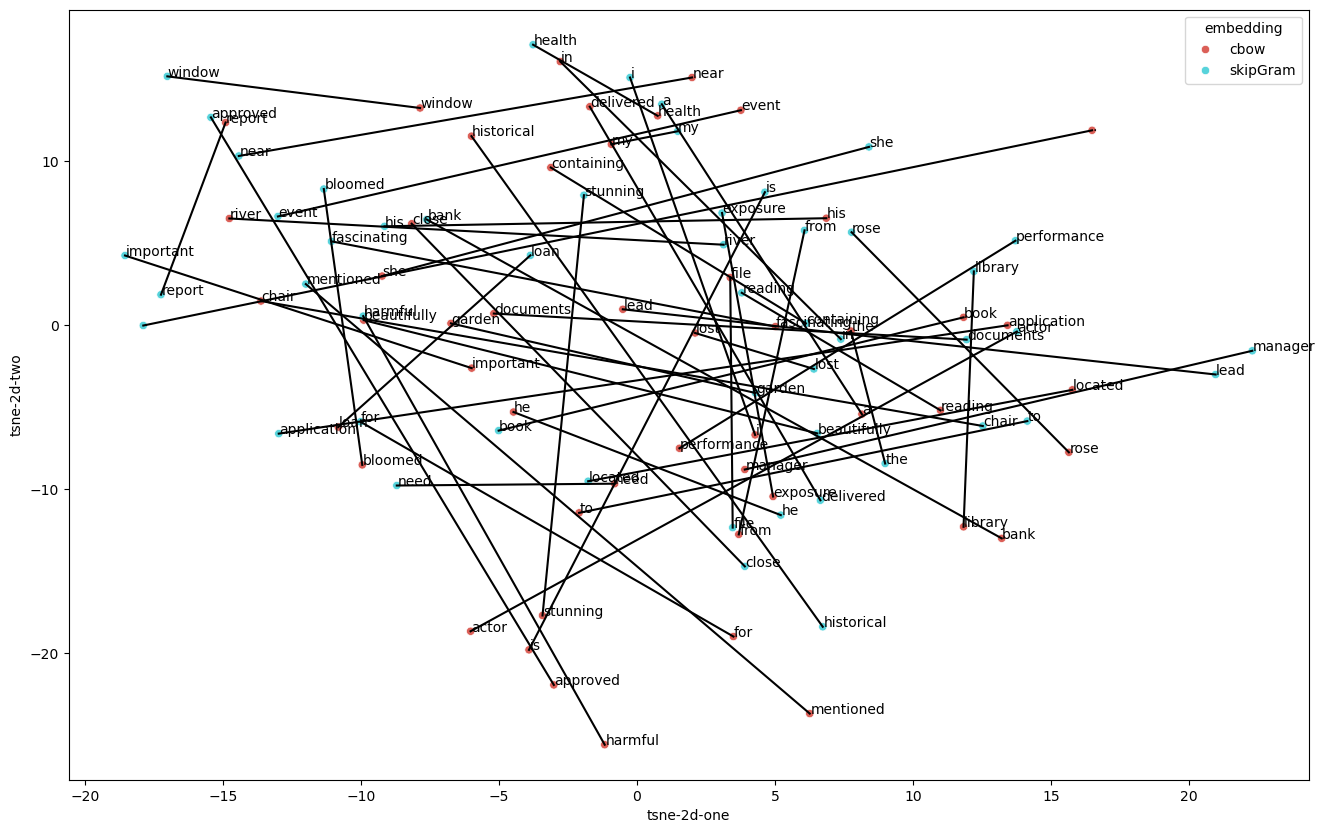

In [304]:
compare_embeddings(cbowTsne, skgmTsne)

## e. Can you find a text that 
Its embedding will be similar in these two algorithms?

## f. Repeat step c with different window sizes. 
Is there a significant change?

### Skip-gram

In [49]:
import pandas as pd  # Import pandas to handle the DataFrame

window_sizes = [1, 2, 3, 4, 5]

# To hold embeddings for comparison and results
previous_embedding_dict = None
differences_data = []  # To store differences

for window_size in window_sizes:
    embedding_dict = train_skipgram_model(corpus, window_size=window_size)
    print(f"Window size: {window_size}\n")
    print("----------------------------------------\n")

    if previous_embedding_dict is not None:
        row_data = {}  # Row data for the DataFrame

        for word in embedding_dict:
            if word in previous_embedding_dict:
                difference = embedding_dict[word] - previous_embedding_dict[word]
                row_data[word] = difference  # Store difference
            else:
                print(f"Word: {word} is new in the current embedding.\n")

        differences_data.append(row_data)  # Append the differences for this window size comparison
        print("----------------------------------------\n")

    previous_embedding_dict = embedding_dict  # Update for the next comparison

# Create a DataFrame from the differences data
comparison_labels = [f"{window_sizes[i]}-{window_sizes[i+1]}" for i in range(len(window_sizes)-1)]
differences_df = pd.DataFrame(differences_data, index=comparison_labels)
print("Differences DataFrame:")
differences_df

Training device: CPU
Epoch 1/10, Loss: 22.2742
Epoch 2/10, Loss: 20.8871
Epoch 3/10, Loss: 20.2711
Epoch 4/10, Loss: 19.8753
Epoch 5/10, Loss: 18.1835
Epoch 6/10, Loss: 17.7685
Epoch 7/10, Loss: 17.3054
Epoch 8/10, Loss: 16.2757
Epoch 9/10, Loss: 16.0639
Epoch 10/10, Loss: 16.0775
Window size: 1

----------------------------------------

Training device: CPU
Epoch 1/10, Loss: 35.3559
Epoch 2/10, Loss: 33.2960
Epoch 3/10, Loss: 31.6648
Epoch 4/10, Loss: 30.7830
Epoch 5/10, Loss: 29.4498
Epoch 6/10, Loss: 27.7548
Epoch 7/10, Loss: 26.1191
Epoch 8/10, Loss: 25.5337
Epoch 9/10, Loss: 24.2765
Epoch 10/10, Loss: 23.6964
Window size: 2

----------------------------------------

----------------------------------------

Training device: CPU
Epoch 1/10, Loss: 45.9348
Epoch 2/10, Loss: 42.6442
Epoch 3/10, Loss: 39.8508
Epoch 4/10, Loss: 37.4961
Epoch 5/10, Loss: 35.4733
Epoch 6/10, Loss: 33.7389
Epoch 7/10, Loss: 32.2173
Epoch 8/10, Loss: 30.9053
Epoch 9/10, Loss: 29.7521
Epoch 10/10, Loss: 28.7

,fascinating,from,is,reading,need,approved,bank,containing,book,garden,...,report,bloomed,application,mentioned,i,rose,my,delivered,to,his
1-2,"[-0.13847154, -0.17525429, 2.5681329, -0.76765...","[1.7335598, -0.51468486, -2.7520795, -1.744585...","[0.005164027, 0.122997284, 2.000492, 1.9476519...","[-1.635007, -1.024919, -0.6611978, 0.6509588, ...","[-0.15589678, 1.8000928, 0.2315442, -0.1434223...","[-0.78650725, -0.07549876, 0.32450396, 3.52729...","[0.71645844, -0.31401506, -0.059844047, -0.895...","[-2.1965497, 0.8014855, -2.3152084, 0.51331574...","[-0.5853123, -2.4594083, 0.014089823, 0.110167...","[-1.1792717, -0.18793559, 1.3039914, -1.445684...",...,"[1.2069244, 1.2115712, -2.0210776, -0.6117628,...","[-0.029218972, 0.90911305, -1.3166729, 1.95318...","[1.3586981, 2.4445024, 0.7724548, -1.7185874, ...","[0.73198104, 0.43526804, -2.351689, -1.7426789...","[0.59257066, 0.44217438, 0.28393397, 0.6518049...","[1.7231449, 0.6943089, 1.2445912, -2.2520726, ...","[-0.20697695, 0.42974105, 1.7295387, 1.0845736...","[2.7990582, -0.49876297, -1.4572362, 0.7893846...","[0.7982246, 1.3325142, 1.4730633, 0.36869875, ...","[-2.581882, 0.41111827, 0.0010781884, -1.88623..."
2-3,"[1.3282855, 0.40087026, 0.10438216, -1.5507215...","[0.8467536, 0.9311049, 0.0008684397, 0.8301116...","[2.482779, -0.89185077, -0.99568534, -2.319122...","[1.2015924, 2.6629772, 1.2001691, -1.0185273, ...","[0.27782902, -0.067376494, -1.7293715, -0.1756...","[1.5811654, 0.7464578, 2.2674978, -0.43592703,...","[0.8901022, 1.3652008, -1.2512295, -1.2288711,...","[2.4119685, -0.014134452, 1.8275473, -0.135739...","[0.6467152, 0.620834, -2.1463833, -0.117310956...","[2.8369818, -0.102927476, -0.3670017, 1.406638...",...,"[-2.0824533, -0.9703377, 0.46534902, 0.0322470...","[-1.0201852, -0.5244953, -0.17949988, -1.88731...","[-1.4354296, -1.8361042, 1.3377992, 1.713068, ...","[0.80637515, -0.25971717, 3.0543556, 2.3795013...","[-0.8756669, -0.9356454, 0.8613554, -0.1855917...","[0.36378306, -0.48566374, -1.7050726, 0.460571...","[-0.1957486, 0.051714398, -2.0589252, -0.06374...","[-1.6472842, -1.2203637, 1.7318423, -0.4673446...","[1.9495795, 0.78003967, -1.5363587, -1.5023102...","[-1.1159755, -0.58809716, 0.037113547, 1.08781..."
3-4,"[0.42031968, -0.23089498, -0.16736323, 2.97392...","[-2.0788605, 0.77682304, 1.4679997, -0.2557364...","[-0.9950956, 0.13996083, -0.45687115, 1.148780...","[-2.1938236, -1.895644, 0.151463, 0.05952335, ...","[0.124805026, -0.21893065, 1.5787303, 1.096146...","[-1.770307, -0.4639668, -1.958244, -1.5647244,...","[-0.72550535, -0.52755237, 2.2812185, 1.334632...","[-1.800436, 0.11127238, -0.7263888, 0.56418073...","[-1.5001159, 0.732154, 1.866613, 1.2737476, -1...","[-1.5799282, -1.1480823, -0.47789076, -0.11395...",...,"[0.50844586, -1.030633, -1.3505316, 0.8540387,...","[1.5506672, 0.48440865, 0.26873642, 0.69129515...","[0.24911615, -0.38805747, -1.676755, -1.058772...","[-2.4343174, 0.5772007, 0.020397663, -1.153524...","[-0.064306796, 0.27166402, -2.0995383, -1.6709...","[1.0537691, -0.101719856, 0.13925613, -0.02229...","[0.93801653, -1.792749, -0.87774456, -0.787278...","[-0.62838453, 0.48936704, -0.25621915, 0.93482...","[-2.066547, -0.714267, 0.06739694, 1.0504483, ...","[0.710243, -0.8042932, 0.44022354, -0.92839193..."
4-5,"[-1.5279403, 1.1193709, -0.023905575, -0.64682...","[1.8496212, -0.43170846, 0.7865343, 0.54692197...","[0.5038631, -0.84391403, -0.5335954, -0.648278...","[1.9241917, 0.7108005, 1.2331263, -1.3287148, ...","[0.09017371, -1.0769044, -1.1177517, -1.597633...","[0.38689613, 0.67724717, 0.89721715, 2.1596973...","[-0.63091123, -1.2739824, -1.0069885, 0.096627...","[0.5357712, -1.6885704, -0.109402865, -1.54295...","[0.3838926, -1.1655433, 1.0726078, -1.2982519,...","[-0.3160101, 1.2537512, 0.5266694, -2.126135, ...",...,"[1.1039317, 1.345763, 2.4962919, -0.36124516, ...","[-1.3292879, -0.7638372, 0.44328892, -0.248963...","[0.6344081, 0.39858568, 0.69885284, 1.1342225,...","[2.0742316, 0.4435957, 0.0929856

We can see that there differences between different window sizes. However, it doesn't seem to have a constant trend. Increasing the window size is supposed to make the model be better at recognizing context, and thus the weights should change drastically for double-meaning words (such as bank) and we can see that it does.

### CBOW

In [ ]:
cbow_embeddings = [train_cbow_model(corpus, window_size=window_size) for window_size in [1,2,3]]

Training device: CPU
Epoch 1/10, Loss: 8.0551
Epoch 2/10, Loss: 7.9250
Epoch 3/10, Loss: 7.7157
Epoch 4/10, Loss: 7.6630
Epoch 5/10, Loss: 7.4479
Epoch 6/10, Loss: 7.3012
Epoch 7/10, Loss: 7.2771
Epoch 8/10, Loss: 7.0555
Epoch 9/10, Loss: 6.8012
Epoch 10/10, Loss: 6.7045
Training device: CPU
Epoch 1/10, Loss: 8.0079
Epoch 2/10, Loss: 7.8641
Epoch 3/10, Loss: 7.6844
Epoch 4/10, Loss: 7.6030
Epoch 5/10, Loss: 7.5182
Epoch 6/10, Loss: 7.4599
Epoch 7/10, Loss: 7.3107
Epoch 8/10, Loss: 7.2029
Epoch 9/10, Loss: 7.0732
Epoch 10/10, Loss: 7.1140
Training device: CPU
Epoch 1/10, Loss: 7.9656
Epoch 2/10, Loss: 7.8191
Epoch 3/10, Loss: 7.7286
Epoch 4/10, Loss: 7.6921
Epoch 5/10, Loss: 7.5347
Epoch 6/10, Loss: 7.5284
Epoch 7/10, Loss: 7.4770
Epoch 8/10, Loss: 7.3413
Epoch 9/10, Loss: 7.3660
Epoch 10/10, Loss: 7.2192


## g. Compare these two models 
In terms of capturing the syntactic and the semantic relationship between words.

## h. Demonstrate the difference between CBOW and Skip-grams
In terms of cosine similarity between the following words:
 - bank, rose, lead, book and file.

### Skip-gram

In [4]:
import pandas as pd
from scipy.spatial.distance import cosine

selected_words = ['bank', 'rose', 'lead', 'book', 'file']  # Words to calculate cosine similarity for

# Initialize an empty DataFrame to store cosine similarities
cosine_similarity_df = pd.DataFrame(index=selected_words, columns=selected_words)

# Calculate cosine similarity for selected word pairs
for word1 in selected_words:
    for word2 in selected_words:
        if word1 != word2:
            # Calculate cosine similarity (1 - cosine distance)
            similarity = 1 - cosine(embedding_dict_skipgram[word1], embedding_dict_skipgram[word2])
            cosine_similarity_df.at[word1, word2] = similarity
        else:
            # Similarity with itself is 1
            cosine_similarity_df.at[word1, word2] = 1.0

# Convert to float type (optional)
cosine_similarity_df = cosine_similarity_df.astype(float)

# Display the resulting DataFrame
cosine_similarity_df

,bank,rose,lead,book,file
bank,1.000000,0.114079,0.544377,0.465391,-0.073770
rose,0.114079,1.000000,-0.417166,0.239949,0.318385
lead,0.544377,-0.417166,1.000000,0.142842,-0.337738
book,0.465391,0.239949,0.142842,1.000000,0.124295
file,-0.073770,0.318385,-0.337738,0.124295,1.000000


### CBOW

## i. How can the subword embeddings be applied?
Michael

# 2. Create example sentences demonstrating: 
how contextual embeddings handle words with multiple meanings (polysemy) differently than static embeddings like Word2Vec.
Barak

In [6]:
import tensorflow_hub as hub
import tensorflow as tf
import numpy as np
import nltk
from nltk.tokenize import word_tokenize

# Make sure to download NLTK data (if not already downloaded)
nltk.download('punkt')

# Load ELMo model from TensorFlow Hub
elmo = hub.load("https://tfhub.dev/google/elmo/3")

# Example sentences for demonstrating polysemy
example_sentences = [
    "He went to the bank to deposit some money.",  # bank as a financial institution
    "The fisherman docked his boat near the river bank.",  # bank as a riverbank
    "She rose from her chair to make an announcement.",  # rose as an action/past tense of rise
    "The rose smelled fragrant and bloomed beautifully.",  # rose as a flower
    "The project manager will lead the team during the meeting.",  # lead as to guide
    "Exposure to lead in paint can cause health issues."  # lead as a toxic substance
]

words_to_compare = ["bank", "rose", "lead"]  # Words to compare

# Function to get contextual embeddings using ELMo
def get_elmo_embeddings(sentences, word):
    """
    Extract contextual embeddings for a specific word from ELMo.
    Arguments:
    - sentences: List of sentences to process.
    - word: The target word to extract embeddings for.

    Returns:
    - A dictionary where keys are sentences and values are embeddings of the target word.
    """
    embeddings = {}

    for sentence in sentences:
        elmo_embeddings = elmo.signatures["default"](tf.constant([sentence]))["elmo"]  # Shape: (1, sentence_length, 1024)
        elmo_embeddings_np = elmo_embeddings.numpy().squeeze()  # Shape: (sentence_length, 1024)
        tokens = word_tokenize(sentence)  # Tokenize using nltk
        if word in tokens:
            word_index = tokens.index(word)  # Find the index of the word
            embeddings[sentence] = elmo_embeddings_np[word_index]  # Extract the embedding for the word
        else:
            embeddings[sentence] = None  # Word not found in the sentence
    return embeddings

# Get static embeddings from the Skip-gram Word2Vec model
def get_skipgram_embedding(word, embedding_dict_skipgram):
    """
    Extract the static embedding for a word from the Skip-gram Word2Vec model.
    """
    return embedding_dict_skipgram.get(word)

# Compare Skip-gram and ELMo embeddings
for word in words_to_compare:
    print(f"\nWord: '{word}'")

    # Contextual embeddings with ELMo
    print("Contextual Embeddings (varies by sentence):")
    elmo_embeddings = get_elmo_embeddings(example_sentences, word)
    for sentence, embedding in elmo_embeddings.items():
        if embedding is not None:
            print(f"  Sentence: {sentence}")
            print(f"    Embedding: {embedding[:5]}...")  # Print only the first 5 dimensions for brevity
        else:
            print(f"  Sentence: {sentence}")
            print("    Embedding: Word not found in the sentence.")

    # Static embedding using Skip-gram Word2Vec
    print("Static Embedding (same for all sentences):")
    skipgram_embedding = get_skipgram_embedding(word, embedding_dict_skipgram)
    if skipgram_embedding is not None:
        print(f"  Embedding: {skipgram_embedding[:5]}...")  # Print only the first 5 dimensions for brevity
    else:
        print("  Embedding: Word not found in the Word2Vec vocabulary.")

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\barak\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!



Word: 'bank'
Contextual Embeddings (varies by sentence):
  Sentence: He went to the bank to deposit some money.
    Embedding: [-0.40484837  0.18932024  0.08644994  0.2684955   0.35230607]...
  Sentence: The fisherman docked his boat near the river bank.
    Embedding: [ 0.10449297  0.3106082  -0.563089   -0.53706545 -0.81824535]...
  Sentence: She rose from her chair to make an announcement.
    Embedding: Word not found in the sentence.
  Sentence: The rose smelled fragrant and bloomed beautifully.
    Embedding: Word not found in the sentence.
  Sentence: The project manager will lead the team during the meeting.
    Embedding: Word not found in the sentence.
  Sentence: Exposure to lead in paint can cause health issues.
    Embedding: Word not found in the sentence.
Static Embedding (same for all sentences):
  Embedding: [ 0.08255051 -0.5002217   0.80496657  0.10599652  0.94017744]...

Word: 'rose'
Contextual Embeddings (varies by sentence):
  Sentence: He went to the bank to depo

# 3. Propose metrics
For evaluating word embeddings that can differentiate between syntactic and semantic relationships.
Michael

# 4. Use the Gensim library 
To train a Word2Vec model on a custom corpus.  
Barak

In [7]:
from gensim.models import Word2Vec
from gensim.models.callbacks import CallbackAny2Vec
from nltk.tokenize import word_tokenize, sent_tokenize
import nltk

# Ensure NLTK dependencies are downloaded
nltk.download('punkt')

class EpochLogger(CallbackAny2Vec):
    """Callback to log information about training progress."""
    def __init__(self):
        self.epoch = 0

    def on_epoch_begin(self, model):
        print(f"Epoch {self.epoch} starting...")

    def on_epoch_end(self, model):
        print(f"Epoch {self.epoch} finished.")
        self.epoch += 1

def train_word2vec(corpus, size=100, window=5, min_count=1, sg=1, epochs=10, workers=4):
    """
    Generalized function to train a Word2Vec model using Gensim, with sentence tokenization
    using NLTK's tokenizer.

    Args:
        corpus (list of str): A list of sentences to train the model on.
        size (int): Dimensionality of the Word2Vec embeddings. Default is 100.
        window (int): Maximum distance between the current and predicted word within a sentence. Default is 5.
        min_count (int): Ignore words with total frequency lower than this. Default is 1.
        sg (int): 1 for skip-gram; 0 for CBOW. Default is 1 (skip-gram).
        epochs (int): Number of training epochs. Default is 10.
        workers (int): Number of threads to use during model training. Default is 4.

    Returns:
        Word2Vec: Trained Word2Vec model.
    """
    # Tokenize each sentence using NLTK
    tokenized_corpus = [word_tokenize(sentence.lower()) for sentence in corpus]

    # Instantiate the logger for monitoring progress
    epoch_logger = EpochLogger()

    # Initialize and train the Word2Vec model
    model = Word2Vec(
        sentences=tokenized_corpus,
        vector_size=size,
        window=window,
        min_count=min_count,
        sg=sg,
        epochs=epochs,
        workers=workers,
        callbacks=[epoch_logger]
    )
    print("Model training completed.")
    return model

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\barak\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


## a. Evaluate the quality of embeddings 
By calculating the cosine similarity for the following word pairs:
```
i. "king" and "queen"  
ii. "man" and "woman"
iii. "apple" and "orange"
```

In [8]:

# Define a logical sentence containing the specified words
corpus = ["The king and the queen ruled the land, while the man and the woman tended to the apple orchard near the orange grove."]

# Train a Word2Vec model on the corpus
model = train_word2vec(corpus=corpus, size=100, window=5, min_count=1, sg=1, epochs=10, workers=4)

# Extract embeddings for the specified words
embedding_dict = {word: model.wv[word] for word in ["king", "queen", "man", "woman", "apple", "orange"]}

# Define the words for cosine similarity calculation
selected_words = ["king", "queen", "man", "woman", "apple", "orange"]

# Initialize a DataFrame to store cosine similarities
cosine_similarity_df = pd.DataFrame(index=selected_words, columns=selected_words)

# Calculate cosine similarity for each word pair
from scipy.spatial.distance import cosine

for word1 in selected_words:
    for word2 in selected_words:
        if word1 != word2:
            # Calculate cosine similarity
            similarity = 1 - cosine(embedding_dict[word1], embedding_dict[word2])
            cosine_similarity_df.at[word1, word2] = similarity
        else:
            # Set self-similarity to 1
            cosine_similarity_df.at[word1, word2] = 1.0

# Convert to float type (optional for better display purposes)
cosine_similarity_df = cosine_similarity_df.astype(float)

# Display the resulting DataFrame of cosine similarities
cosine_similarity_df

Epoch 0 starting...
Epoch 0 finished.
Epoch 1 starting...
Epoch 1 finished.
Epoch 2 starting...
Epoch 2 finished.
Epoch 3 starting...
Epoch 3 finished.
Epoch 4 starting...
Epoch 4 finished.
Epoch 5 starting...
Epoch 5 finished.
Epoch 6 starting...
Epoch 6 finished.
Epoch 7 starting...
Epoch 7 finished.
Epoch 8 starting...
Epoch 8 finished.
Epoch 9 starting...
Epoch 9 finished.
Model training completed.


,king,queen,man,woman,apple,orange
king,1.000000,-0.044282,0.041448,0.015665,0.007389,-0.260190
queen,-0.044282,1.000000,-0.028988,-0.255465,0.253951,0.109047
man,0.041448,-0.028988,1.000000,0.096001,0.116301,-0.148974
woman,0.015665,-0.255465,0.096001,1.000000,0.004475,-0.010320
apple,0.007389,0.253951,0.116301,0.004475,1.000000,-0.031320
orange,-0.260190,0.109047,-0.148974,-0.010320,-0.031320,1.000000


## b. Write a brief explanation of the results.

We can see that the word couples: "king" and "queen", "man" and "woman", "apple" and "orange" may have a similar context, but have a pretty weak cosine similarity when it comes to a Word2vec model. It could mean that a Word2Vec model looks at the words independently and thus words with similar context might not necessarily have a strong cosine similarity, or it could be that the embedding captures another similarity.

# 5. Train the GloVe model 
Using the glove-python package on a subset of a publicly available dataset (e.g., Wikipedia, or a smaller custom corpus).

Michael

## a. Use t-SNE or PCA 
To visualize the embeddings in 2D.

## b. Analyze the clustering patterns observed in the visualization.